# 02 — Merchandise revenue and identified customers

Answers three questions using the **same** preparation as `01_data_preparation.ipynb`.
SQL Server Raw stays the source of truth. No Silver/Gold tables.
This notebook starts from a **fresh kernel** (it reloads from SQL).

## 0. Setup and reload Raw (SELECT only)

In [1]:
from datetime import datetime
from decimal import Decimal, ROUND_HALF_UP
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import pyodbc

PROJECT = Path("..").resolve()
if not (PROJECT / "scripts").exists():
    PROJECT = Path(".").resolve()
TABLES = PROJECT / "outputs" / "tables"
FIGURES = PROJECT / "outputs" / "figures"
TABLES.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

def unique_output_path(path: Path) -> Path:
    """If the target exists, write a timestamped file instead of overwriting."""
    if not path.exists():
        return path
    stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    return path.with_name(f"{path.stem}_{stamp}{path.suffix}")

server = r".\MSSQLSERVER02"
database = "RetailAnalytics"
driver = "ODBC Driver 18 for SQL Server"
connection_string = (
    f"DRIVER={{{driver}}};"
    f"SERVER={server};"
    f"DATABASE={database};"
    "Trusted_Connection=yes;"
    "TrustServerCertificate=yes;"
)

read_sql = """
SELECT
    raw_row_id, InvoiceNo, StockCode, Description, Quantity,
    InvoiceDate, UnitPrice, CustomerID, Country, source_file, loaded_at
FROM raw.online_retail;
"""

connection = pyodbc.connect(connection_string)
try:
    df_raw = pd.read_sql(read_sql, connection)
finally:
    connection.close()

df = df_raw.copy()
EXPECTED_ROWS = 541_909
assert len(df) == EXPECTED_ROWS
print("Loaded", len(df), "rows")

C:\Users\Admin\AppData\Local\Temp\ipykernel_37968\3707417734.py:44: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_raw = pd.read_sql(read_sql, connection)


Loaded 541909 rows


## 1. Same preparation as notebook 01

Types, flags, StockCode map, duplicates (keep extras), and merchandise masks.

In [2]:
def penny(x) -> Decimal:
    return Decimal(str(float(x))).quantize(Decimal("0.01"), rounding=ROUND_HALF_UP)


def penny_sum(series: pd.Series) -> Decimal:
    return penny(float(series.sum())) if len(series) else Decimal("0.00")


for col in ["InvoiceNo", "StockCode", "CustomerID", "Country"]:
    df[col] = df[col].astype("string")
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
desc = df["Description"].astype("string").str.strip()
df["Description_clean"] = desc.mask(desc.eq(""), pd.NA)
df["UnitPrice"] = df["UnitPrice"].astype("float64")
df["line_value"] = df["Quantity"] * df["UnitPrice"]

df["is_c_prefix_invoice"] = df["InvoiceNo"].str.upper().str.startswith("C", na=False)

# Same explicit map as notebook 01 (executed counts: postage 2110, manual 571).
STOCKCODE_GROUP = {
    "POST": "postage_carriage",
    "DOT": "postage_carriage",
    "C2": "postage_carriage",
    "AMAZONFEE": "fees_commission",
    "CRUK": "fees_commission",
    "BANK CHARGES": "fees_commission",
    "D": "discount",
    "M": "manual_unresolved",
    "S": "samples",
    "B": "bad_debt_adjustment",
}
df["code_group"] = df["StockCode"].map(STOCKCODE_GROUP).astype("string")
df["code_group"] = df["code_group"].fillna("merchandise_candidate")
adjust_bad_debt = df["Description"].astype("string").str.contains(
    "Adjust bad debt", case=False, na=False
)
df.loc[adjust_bad_debt, "code_group"] = "bad_debt_adjustment"

print("code_group counts (notebook 01 mapping, not rewritten):")
print(df["code_group"].value_counts())

code_group counts (notebook 01 mapping, not rewritten):
code_group
merchandise_candidate    538998
postage_carriage           2110
manual_unresolved           571
fees_commission              87
discount                     77
samples                      63
bad_debt_adjustment           3
Name: count, dtype: Int64


In [3]:
BUSINESS_COLS = [
    "InvoiceNo", "StockCode", "Description", "Quantity",
    "InvoiceDate", "UnitPrice", "CustomerID", "Country",
]
g = df.groupby(BUSINESS_COLS, dropna=False, sort=False)
df["duplicate_group_size"] = g["raw_row_id"].transform("size")
# Unique raw_row_id: rank first keeps the lowest id as the non-extra row.
df["duplicate_row_number"] = g["raw_row_id"].rank(method="first")
df["is_duplicate_extra"] = (df["duplicate_group_size"] > 1) & (df["duplicate_row_number"] > 1)

df["invoice_month"] = df["InvoiceDate"].dt.to_period("M")
max_ts = df["InvoiceDate"].max()
df["is_final_partial_month"] = df["invoice_month"] == max_ts.to_period("M")

is_merch = df["code_group"] == "merchandise_candidate"
mask_sale = (
    is_merch & (df["Quantity"] > 0) & (df["UnitPrice"] > 0) & ~df["is_c_prefix_invoice"]
)
mask_neg = is_merch & (df["Quantity"] < 0) & (df["UnitPrice"] > 0)
mask_id_purchase = mask_sale & df["CustomerID"].notna()
keep = ~df["is_duplicate_extra"]

NB01_GROSS = Decimal("10272121.42")
NB01_NEG = Decimal("-478724.18")
NB01_ID_GROSS = Decimal("8761066.65")
assert penny_sum(df.loc[mask_sale, "line_value"]) == NB01_GROSS
assert penny_sum(df.loc[mask_neg, "line_value"]) == NB01_NEG
assert penny_sum(df.loc[mask_id_purchase, "line_value"]) == NB01_ID_GROSS
assert len(df) == EXPECTED_ROWS
print("Reconciled to notebook 01 merchandise totals (nearest penny).")

Reconciled to notebook 01 merchandise totals (nearest penny).


## 2. Question 1 — Monthly merchandise revenue

Each line is dated by its own `InvoiceDate`. Negative lines are not matched to original sales.
Purchase invoices and customers use the **positive-sale** mask only.

Dec 2010 starts 2010-12-01 (not labelled incomplete). Dec 2011 ends 2011-12-09 (partial; MoM vs November is not a full-month change).

In [4]:
sales_m = (
    df.loc[mask_sale]
    .groupby("invoice_month", dropna=False)
    .agg(
        gross_merchandise_sales=("line_value", "sum"),
        purchase_invoices=("InvoiceNo", "nunique"),
        identified_purchasing_customers=("CustomerID", "nunique"),
    )
)
neg_m = (
    df.loc[mask_neg]
    .groupby("invoice_month", dropna=False)["line_value"]
    .sum()
    .rename("negative_merchandise_value")
)
net_no_extra_m = (
    df.loc[(mask_sale | mask_neg) & keep]
    .groupby("invoice_month", dropna=False)["line_value"]
    .sum()
    .rename("net_excluding_duplicate_extras")
)

monthly = sales_m.join(neg_m, how="outer").join(net_no_extra_m, how="outer")
monthly = monthly.fillna(
    {
        "gross_merchandise_sales": 0.0,
        "negative_merchandise_value": 0.0,
        "purchase_invoices": 0,
        "identified_purchasing_customers": 0,
        "net_excluding_duplicate_extras": 0.0,
    }
)
monthly = monthly.sort_index()
monthly["net_merchandise_value"] = (
    monthly["gross_merchandise_sales"] + monthly["negative_merchandise_value"]
)
den = monthly["gross_merchandise_sales"].replace(0, pd.NA)
monthly["abs_negative_pct_of_gross"] = (
    monthly["negative_merchandise_value"].abs() / den * 100
)
monthly["is_partial_final_month"] = monthly.index == max_ts.to_period("M")
monthly["net_mom_change"] = monthly["net_merchandise_value"].shift(1)
monthly["net_mom_change"] = monthly["net_merchandise_value"] - monthly["net_mom_change"]
# First month has no prior month. Partial Dec 2011: do not treat MoM as full-month growth.
monthly.loc[monthly["is_partial_final_month"], "net_mom_change"] = pd.NA
monthly["month_note"] = ""
monthly.loc[monthly.index[0], "month_note"] = "First observed month (starts 2010-12-01); no MoM."
monthly.loc[monthly["is_partial_final_month"], "month_note"] = (
    "Incomplete month (ends 2011-12-09); full-month MoM left missing."
)

monthly_out = monthly.reset_index().rename(columns={"invoice_month": "month"})
monthly_out["month"] = monthly_out["month"].astype(str)
print(monthly_out.to_string(index=False))

complete_months = monthly_out.loc[~monthly_out["is_partial_final_month"]]
lowest_complete = complete_months.loc[complete_months["net_merchandise_value"].idxmin()]
highest_complete = complete_months.loc[complete_months["net_merchandise_value"].idxmax()]
print(
    "Complete-month net min:",
    lowest_complete["month"],
    penny(lowest_complete["net_merchandise_value"]),
)
print(
    "Complete-month net max:",
    highest_complete["month"],
    penny(highest_complete["net_merchandise_value"]),
)

  month  gross_merchandise_sales  purchase_invoices  identified_purchasing_customers  negative_merchandise_value  net_excluding_duplicate_extras  net_merchandise_value  abs_negative_pct_of_gross  is_partial_final_month  net_mom_change                                                       month_note
2010-12               778010.910               1550                              884                   -17607.86                      758169.640             760403.050                   2.263189                   False             NaN                First observed month (starts 2010-12-01); no MoM.
2011-01               671992.410               1081                              739                   -91526.30                      578914.410             580466.110                  13.620139                   False     -179936.940                                                                 
2011-02               508952.870               1093                              757                

Monthly value totals match full merchandise totals.


Saved D:\Python Projects\retail-transaction-analytics\outputs\figures\monthly_merchandise_revenue_20260901_231128.png


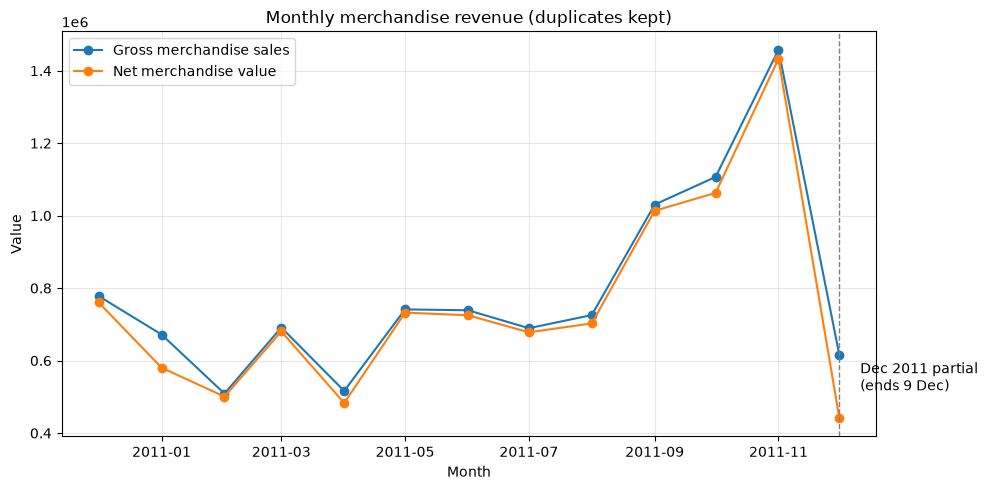

In [5]:
assert penny_sum(monthly["gross_merchandise_sales"]) == NB01_GROSS
assert penny_sum(monthly["negative_merchandise_value"]) == NB01_NEG
assert penny_sum(monthly["net_merchandise_value"]) == penny(NB01_GROSS + NB01_NEG)
print("Monthly value totals match full merchandise totals.")

fig, ax = plt.subplots(figsize=(10, 5))
x = monthly.index.to_timestamp()
ax.plot(x, monthly["gross_merchandise_sales"], marker="o", label="Gross merchandise sales")
ax.plot(x, monthly["net_merchandise_value"], marker="o", label="Net merchandise value")
partial = monthly.index[monthly["is_partial_final_month"]][0].to_timestamp()
ax.axvline(partial, color="gray", linestyle="--", linewidth=1)
ax.annotate(
    "Dec 2011 partial\n(ends 9 Dec)",
    xy=(partial, monthly["net_merchandise_value"].iloc[-1]),
    xytext=(15, 20),
    textcoords="offset points",
)
ax.set_title("Monthly merchandise revenue (duplicates kept)")
ax.set_xlabel("Month")
ax.set_ylabel("Value")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
monthly_fig_path = unique_output_path(FIGURES / "monthly_merchandise_revenue.png")
fig.savefig(monthly_fig_path, dpi=120)
print("Saved", monthly_fig_path)
plt.show()

## 3. Question 2 — Country contribution

Shares use **all countries** as the denominator. Distinct customers are not added across countries.

In [6]:
sales_c = (
    df.loc[mask_sale]
    .groupby("Country", dropna=False)
    .agg(
        gross_merchandise_sales=("line_value", "sum"),
        purchase_invoices=("InvoiceNo", "nunique"),
        identified_purchasing_customers=("CustomerID", "nunique"),
    )
)
neg_c = (
    df.loc[mask_neg]
    .groupby("Country", dropna=False)["line_value"]
    .sum()
    .rename("negative_merchandise_value")
)
net_no_extra_c = (
    df.loc[(mask_sale | mask_neg) & keep]
    .groupby("Country", dropna=False)["line_value"]
    .sum()
    .rename("net_excluding_duplicate_extras")
)
country = sales_c.join(neg_c, how="outer").join(net_no_extra_c, how="outer")
country = country.fillna(
    {
        "gross_merchandise_sales": 0.0,
        "negative_merchandise_value": 0.0,
        "purchase_invoices": 0,
        "identified_purchasing_customers": 0,
        "net_excluding_duplicate_extras": 0.0,
    }
)
country["net_merchandise_value"] = (
    country["gross_merchandise_sales"] + country["negative_merchandise_value"]
)
total_net = country["net_merchandise_value"].sum()
country["pct_of_net_merchandise"] = country["net_merchandise_value"] / total_net * 100
country = country.sort_values("net_merchandise_value", ascending=False)

assert penny_sum(country["gross_merchandise_sales"]) == NB01_GROSS
assert penny_sum(country["negative_merchandise_value"]) == NB01_NEG
print(country.head(10).to_string())
print("\nCountries in summary:", len(country))

                gross_merchandise_sales  purchase_invoices  identified_purchasing_customers  negative_merchandise_value  net_excluding_duplicate_extras  net_merchandise_value  pct_of_net_merchandise
Country                                                                                                                                                                                               
United Kingdom              8748250.023              17901                             3916                  -445843.38                     8282078.723            8302406.643               84.775553
Netherlands                  283889.340                 93                                9                     -409.80                      283479.540             283479.540                2.894599
EIRE                         271164.300                282                                3                   -11500.84                      259380.020             259663.460                2.651414
Germa

         group       gross   negative         net  pct_of_net
United Kingdom 8748250.023 -445843.38 8302406.643   84.775553
        non_UK 1523871.400  -32880.80 1490990.600   15.224447


Saved D:\Python Projects\retail-transaction-analytics\outputs\figures\top_10_countries_net_merchandise_20260901_231130.png


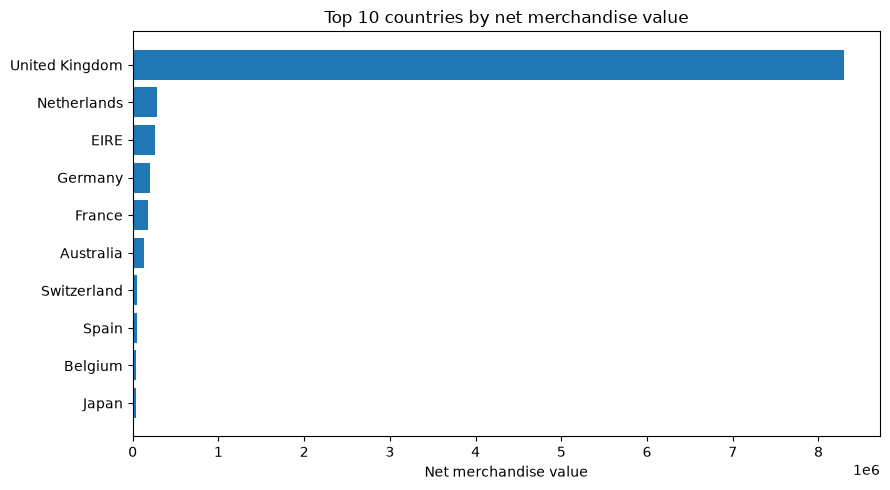

In [7]:
uk = df["Country"] == "United Kingdom"
uk_summary = pd.DataFrame(
    {
        "group": ["United Kingdom", "non_UK"],
        "gross": [
            df.loc[mask_sale & uk, "line_value"].sum(),
            df.loc[mask_sale & ~uk, "line_value"].sum(),
        ],
        "negative": [
            df.loc[mask_neg & uk, "line_value"].sum(),
            df.loc[mask_neg & ~uk, "line_value"].sum(),
        ],
    }
)
uk_summary["net"] = uk_summary["gross"] + uk_summary["negative"]
uk_summary["pct_of_net"] = uk_summary["net"] / uk_summary["net"].sum() * 100
print(uk_summary.to_string(index=False))

top10c = country.head(10).sort_values("net_merchandise_value")
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top10c.index.astype(str), top10c["net_merchandise_value"])
ax.set_xlabel("Net merchandise value")
ax.set_title("Top 10 countries by net merchandise value")
fig.tight_layout()
country_fig_path = unique_output_path(FIGURES / "top_10_countries_net_merchandise.png")
fig.savefig(country_fig_path, dpi=120)
print("Saved", country_fig_path)
plt.show()

## 4. Question 3 — Top identified customers

Outer join so negative-only customers are kept. Purchase counts, units, and dates use the **positive-sale** mask only.
Ranks use pandas `rank(method="min")`: ties share the best rank (1, 1, 3). First/last dates are first/last **observed** merchandise purchase in this extract, not lifetime first-ever.

In [8]:
id_sale = mask_sale & df["CustomerID"].notna()
id_neg = mask_neg & df["CustomerID"].notna()

sales_u = (
    df.loc[id_sale]
    .groupby("CustomerID", dropna=False)
    .agg(
        gross_merchandise_sales=("line_value", "sum"),
        positive_sale_invoices=("InvoiceNo", "nunique"),
        positive_merchandise_units=("Quantity", "sum"),
        first_observed_merchandise_purchase=("InvoiceDate", "min"),
        last_observed_merchandise_purchase=("InvoiceDate", "max"),
    )
)
neg_u = (
    df.loc[id_neg]
    .groupby("CustomerID", dropna=False)["line_value"]
    .sum()
    .rename("negative_merchandise_value")
)
net_no_extra_u = (
    df.loc[(id_sale | id_neg) & keep]
    .groupby("CustomerID", dropna=False)["line_value"]
    .sum()
    .rename("net_excluding_duplicate_extras")
)

customer = sales_u.join(neg_u, how="outer").join(net_no_extra_u, how="outer")
customer["gross_merchandise_sales"] = customer["gross_merchandise_sales"].fillna(0.0)
customer["negative_merchandise_value"] = customer["negative_merchandise_value"].fillna(0.0)
customer["positive_sale_invoices"] = customer["positive_sale_invoices"].fillna(0).astype(int)
customer["positive_merchandise_units"] = customer["positive_merchandise_units"].fillna(0)
customer["net_excluding_duplicate_extras"] = customer["net_excluding_duplicate_extras"].fillna(0.0)
customer["net_merchandise_value"] = (
    customer["gross_merchandise_sales"] + customer["negative_merchandise_value"]
)
customer["rank_net"] = customer["net_merchandise_value"].rank(method="min", ascending=False)
customer["rank_gross"] = customer["gross_merchandise_sales"].rank(method="min", ascending=False)
customer["rank_net_minus_rank_gross"] = customer["rank_net"] - customer["rank_gross"]

assert penny_sum(customer["gross_merchandise_sales"]) == NB01_ID_GROSS
assert penny_sum(customer["negative_merchandise_value"]) == penny_sum(df.loc[id_neg, "line_value"])
print("Customers in summary:", len(customer))
print("Negative-only customers (no positive sale):", int((customer["positive_sale_invoices"] == 0).sum()))

Customers in summary: 4362
Negative-only customers (no positive sale): 28


Customers with negative net merchandise value: 30

Largest rank gaps (rank_net minus rank_gross; negative means better on net than gross):
CustomerID
13799   -47.0
17502   -47.0
18196   -47.0
17733   -46.0
12735   -46.0
CustomerID
16446    4316.0
12346    4314.0
12454    3878.0
12607    3203.0
16546    2420.0

Top 20 by net:
            gross_merchandise_sales  negative_merchandise_value  net_merchandise_value  positive_sale_invoices  rank_net  rank_gross
CustomerID                                                                                                                          
14646                     279138.02                     -360.00              278778.02                      72       1.0         1.0
18102                     259657.30                        0.00              259657.30                      60       2.0         2.0
17450                     194550.79                    -4815.26              189735.53                      46       3.0         3.0
14911   

Saved D:\Python Projects\retail-transaction-analytics\outputs\figures\top_10_customers_net_merchandise_20260901_231131.png


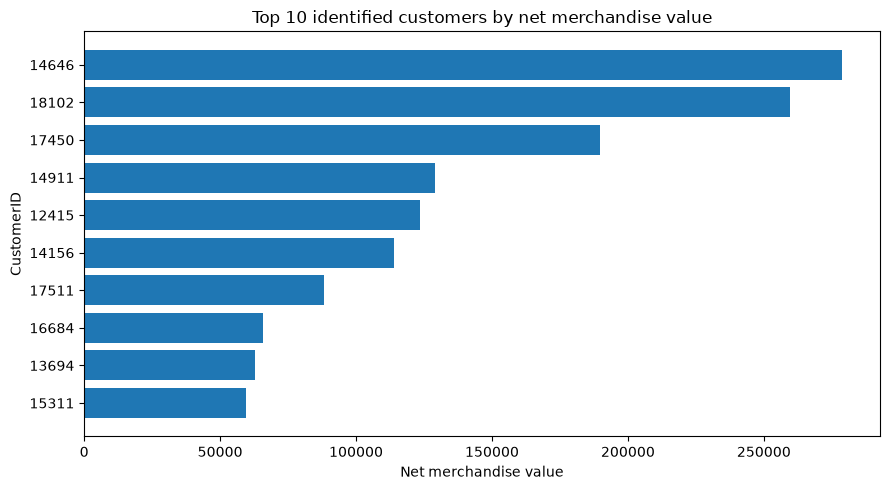

In [9]:
n_neg_net = int((customer["net_merchandise_value"] < 0).sum())
print("Customers with negative net merchandise value:", n_neg_net)
print("\nLargest rank gaps (rank_net minus rank_gross; negative means better on net than gross):")
print(
    customer["rank_net_minus_rank_gross"]
    .sort_values()
    .head(5)
    .to_string()
)
print(
    customer["rank_net_minus_rank_gross"]
    .sort_values(ascending=False)
    .head(5)
    .to_string()
)

top20 = customer.sort_values(["net_merchandise_value", "CustomerID"], ascending=[False, True]).head(20)
print("\nTop 20 by net:")
print(top20[["gross_merchandise_sales", "negative_merchandise_value", "net_merchandise_value",
            "positive_sale_invoices", "rank_net", "rank_gross"]].to_string())

top10u = top20.head(10).sort_values("net_merchandise_value")
fig, ax = plt.subplots(figsize=(9, 5))
labels = top10u.index.astype(str)
ax.barh(range(len(top10u)), top10u["net_merchandise_value"])
ax.set_yticks(range(len(top10u)), labels)
ax.set_xlabel("Net merchandise value")
ax.set_ylabel("CustomerID")
ax.set_title("Top 10 identified customers by net merchandise value")
fig.tight_layout()
customer_fig_path = unique_output_path(FIGURES / "top_10_customers_net_merchandise.png")
fig.savefig(customer_fig_path, dpi=120)
print("Saved", customer_fig_path)
plt.show()

## 5. Identified vs unidentified split and duplicate sensitivity

In [10]:
id_neg_value = penny_sum(df.loc[id_neg, "line_value"])
unid_gross = penny_sum(df.loc[mask_sale & df["CustomerID"].isna(), "line_value"])
unid_neg = penny_sum(df.loc[mask_neg & df["CustomerID"].isna(), "line_value"])
id_net = NB01_ID_GROSS + id_neg_value
unid_net = unid_gross + unid_neg
all_net = NB01_GROSS + NB01_NEG
assert id_net + unid_net == all_net
print("Identified gross / signed neg / net:", NB01_ID_GROSS, id_neg_value, id_net)
print("Unidentified gross / signed neg / net:", unid_gross, unid_neg, unid_net)
print("All-customer net:", all_net)

net_all = penny(NB01_GROSS + NB01_NEG)
net_no_extra = penny_sum(df.loc[(mask_sale | mask_neg) & keep, "line_value"])
dup_diff = net_all - net_no_extra
dup_pct = (dup_diff / net_all * 100) if net_all != 0 else None
print("Net with extras vs without:", net_all, net_no_extra, "diff", dup_diff, "pct", dup_pct)

country_rank_all = country.sort_values("net_merchandise_value", ascending=False).index.tolist()[:10]
country_rank_ex = country.sort_values("net_excluding_duplicate_extras", ascending=False).index.tolist()[:10]
print("Top 10 countries same with/without extras:", country_rank_all == country_rank_ex)
if country_rank_all != country_rank_ex:
    print("  with extras:", country_rank_all)
    print("  no extras:", country_rank_ex)

cust_all = customer.sort_values("net_merchandise_value", ascending=False).index.astype(str).tolist()[:10]
cust_ex = customer.sort_values("net_excluding_duplicate_extras", ascending=False).index.astype(str).tolist()[:10]
print("Top 10 customers same with/without extras:", cust_all == cust_ex)
if cust_all != cust_ex:
    print("  with extras:", cust_all)
    print("  no extras:", cust_ex)

Identified gross / signed neg / net: 8761066.65 -474403.33 8286663.32
Unidentified gross / signed neg / net: 1511054.77 -4320.85 1506733.92
All-customer net: 9793397.24
Net with extras vs without: 9793397.24 9772006.52 diff 21390.72 pct 0.2184198136335374465010468625
Top 10 countries same with/without extras: True
Top 10 customers same with/without extras: False
  with extras: ['14646', '18102', '17450', '14911', '12415', '14156', '17511', '16684', '13694', '15311']
  no extras: ['14646', '18102', '17450', '14911', '12415', '14156', '17511', '16684', '13694', '16029']


## 6. Save tables

In [11]:
for frame, name in [
    (monthly_out, "monthly_revenue.csv"),
    (country.reset_index(), "country_revenue.csv"),
    (customer.reset_index(), "customer_revenue.csv"),
    (top20.reset_index(), "top_customers.csv"),
]:
    out = unique_output_path(TABLES / name)
    frame.to_csv(out, index=False)
    print("Saved", out)

Saved D:\Python Projects\retail-transaction-analytics\outputs\tables\monthly_revenue_20260901_231132.csv
Saved D:\Python Projects\retail-transaction-analytics\outputs\tables\country_revenue_20260901_231132.csv
Saved D:\Python Projects\retail-transaction-analytics\outputs\tables\customer_revenue_20260901_231132.csv
Saved D:\Python Projects\retail-transaction-analytics\outputs\tables\top_customers_20260901_231132.csv


## 7. Findings

Figures are from this executed notebook. Merchandise totals match notebook 01 to the nearest penny: gross **10,272,121.42**, signed negative **−478,724.18**, identified-customer gross purchases **8,761,066.65**. Net merchandise value (gross + signed negative) is **9,793,397.24**. Rankings use `rank(method="min")` (ties share the best rank). Duplicate extras stay in the baseline.

Executed `code_group` counts (notebook 01 mapping, unchanged): merchandise_candidate **538,998**; postage_carriage **2,110**; manual_unresolved **571**; fees_commission **87**; discount **77**; samples **63**; bad_debt_adjustment **3**. SQL profiling 4.1 had M = 572 and POST+DOT+C2 = 2,109 (one-row difference). This notebook did **not** reclassify that row.

### Question 1 — Monthly merchandise revenue

- Among **complete** months (excluding the flagged partial final month), net merchandise value is lowest in **2011-04** (**482,992.88**) and highest in **2011-11** (**1,432,734.99**). February is the lowest complete month by **gross** (**508,952.87**), not by net. November also has the most purchase invoices (**2,751**) and identified purchasing customers (**1,660**), and the largest complete-month MoM rise in net (**+370,040.66**). September–November are the three highest complete months by net (**1,013,455.68**, **1,062,694.33**, **1,432,734.99**).
- **2011-01** net is **580,466.11**, down **179,936.94** from December 2010 (**760,403.05**). Among complete months, January has the highest abs-negative / gross (**13.62%**), versus **2.26%** in December 2010. **2011-04** is the largest complete-month MoM decline (net **482,992.88**, MoM **−197,597.76**; abs-negative **6.45%** of gross).
- **2011-12** is incomplete (ends 2011-12-09). Its net is **441,374.84** and abs-negative / gross is **28.29%**. Full-month MoM versus November is left missing and is **not** a full-month growth or decline. December 2010 is the first observed month (extract starts 2010-12-01); it is not labelled incomplete, and it has no prior month for MoM.

### Question 2 — Country contribution

- The **United Kingdom** accounts for **8,302,406.64** net merchandise value, **84.78%** of the all-country total (**9,793,397.24**). Non-UK net is **1,490,990.60** (**15.22%**). Shares use all **38** countries, not the top 10.
- After the UK, the next countries by net are the **Netherlands** (**283,479.54**, **2.89%**), **EIRE** (**259,663.46**, **2.65%**), **Germany** (**200,808.40**, **2.05%**), and **France** (**182,163.39**, **1.86%**). UK identified purchasing customers on the positive-sale mask: **3,916**; do not add country-level distinct counts to get a global distinct count.
- UK signed negative merchandise value is **−445,843.38** of the global **−478,724.18**. Hong Kong appears in the country file with purchase invoices but **0** identified purchasing customers (unidentified-customer sales).

### Question 3 — Top identified customers

- The customer summary has **4,362** identified CustomerIDs with merchandise sales or negative merchandise value, including **28** with no observed positive sale. Identified-customer net is **8,286,663.32** (gross **8,761,066.65**, signed negative **−474,403.33**). Unidentified net is **1,506,733.92** (gross **1,511,054.77**, signed negative **−4,320.85**). Unidentified net is **not** a residual that must sit below identified net; it is **15.38%** of all-customer net.
- Top three by net: **14646** (**278,778.02**), **18102** (**259,657.30**), **17450** (**189,735.53**). **30** customers have negative net merchandise value.
- Largest **worse** net-vs-gross ranks (rank_net − rank_gross): **16446** (**+4,316**), **12346** (**+4,314**), **12454** (**+3,878**). Largest **better** net-vs-gross ranks: **13799**, **17502**, and **18196** (each **−47**).

### Duplicate sensitivity

- Net including extras **9,793,397.24** versus excluding extras **9,772,006.52**: difference **21,390.72** (**0.22%** of baseline net).
- Top **10 countries** by net are **unchanged**. Top **10 customers** change: **15311** (with extras) is replaced by **16029** (without extras).

### Limitations

- December 2011 is a **partial** month (through 9 Dec); do not treat its comparison with November as a full-month change.
- Unidentified customers have no `CustomerID` and are excluded from question 3; they still contribute merchandise value.
- `merchandise_candidate` is a **provisional** classification from notebook 01.
- Negative merchandise value is signed line value; it is **not** confirmed cash refunds and is not matched back to original purchases here.
- Duplicate extras remain in the baseline; excluding them is a sensitivity only (lowest `raw_row_id` retained within exact 8-column groups).
